# DMSP-OLS / VIIRS-DNB Harmonizer — Mini-Tutorial

**Audience.** Senior data scientist comfortable with Python, ML, and
raster geospatial work, but new to nighttime lights (NTL) and the
specific literature on cross-platform harmonization.

**Goal.** Walk through the WB-LEN harmonizer pipeline end to end on a
small region (Paris, ~1°×1°), explaining the math, key assumptions, and
design decisions at each stage. Plots at each stage make the data
concrete; references at the bottom point to the foundational literature.

**Differences from previous tool** See the repo `README.md` for the migration narrative.

**Runtime.** ~20 minutes cold start against the public
`s3://globalnightlight/` bucket (no authentication required); ~3–5 minutes
on a warm cache. The bottleneck is network-bound windowed COG reads for
12 months of DMSP and VIIRS orbits. All reads are cached under `/tmp/`
after the first run, so re-executing individual stages is fast.

---

## 1. Background: nighttime lights as a remote sensing dataset

**Why NTL?** Spaceborne measurements of light emitted from the Earth's
surface at night correlate strongly with human presence, energy use, and
economic activity. They've been used as proxies for GDP at sub-national
scales (Henderson, Storeygard, Weil 2012), to detect rural
electrification (Min et al. 2013), and to track urbanization, conflict,
and disaster recovery.

**The two instruments we care about.**

| Sensor | Period | Native res. | Encoding | Notes |
|---|---|---|---|---|
| **DMSP-OLS** | 1992–2013 (LEN extends through 2017) | 30 arc-sec (~1 km) | uint8 DN, 0–63 | Onboard amplification with thermal feedback; saturates over urban cores; the same physical light produces different DN values across satellites and across years. |
| **VIIRS-DNB** | 2012–present | 15 arc-sec (~500 m) | float32 radiance (nW/cm²/sr) | Calibrated radiometric signal, much wider dynamic range; sensitive to dim lights and lunar contamination. |

**Why harmonize?** A meaningful long time series (1992–present) needs
both sensors. But the two record fundamentally different signals on
different scales, and even within the DMSP era there's substantial
satellite-to-satellite drift. Harmonization is the procedure that maps
VIIRS-DNB onto a DMSP-DN-like scale and intercalibrates the DMSP
satellites to a common reference, producing a single coherent series.

Two well-cited references to anchor the literature:
- Elvidge et al. 2017: VIIRS-DNB overview and applications
  (*International Journal of Remote Sensing* 38(21), 5860–5879).
- Li et al. 2017: the DMSP intercalibration recipe this codebase uses
  (*Remote Sensing* 9(6), 637).

---

## 2. The data: World Bank Light Every Night (LEN)

WB-LEN is a public S3 archive at `s3://globalnightlight/` (anonymous
access, no auth) hosting **nightly orbit COGs** for both sensors, plus
STAC catalogs for discovery. This is qualitatively different from the
EOG/NOAA *annual composites* that older NTL workflows used: we now
have the per-orbit raw observations, with the per-pixel auxiliary
layers needed to do our own masking and compositing.

**Per-orbit layer bundle** (only the three we use):

| Layer | DMSP filename | VIIRS filename | Units | NoData |
|---|---|---|---|---|
| Radiance | `*.OIS.vis.co.tif` (uint8 DN) | `SVDNB_*.rade9.co.tif` (float32) | DN 0–63 / nW·cm⁻²·sr⁻¹ | sentinel (e.g. 255 / -999.3) |
| Lunar illuminance | `*.OIS.li.co.tif` | `GDNBO_*.li.co.tif` | lux | -1.0 / -999.3 |
| QA flag bitfield | `*.OIS.flag.co.tif` (uint16) | `*.vflag.co.tif` (uint32) | bit-packed | (none) |

Two important conventions:

1. **Lunar illuminance is a confounder** at the pixel level, VIIRS-DNB
   in particular detects moonlight scattered through the atmosphere as
   apparent surface brightness. The *Earth Observation Group* convention
   used to build their published composites is to keep only pixels
   acquired under effectively zero moonlight (a specific bit in the QA
   flag layer). We reproduce that convention as the default mask mode.
2. **The two sensors use different bit positions** for the zero-LI flag:
   bit 11 for DMSP, bit 5 for VIIRS. The `harmonizer.constants` module
   centralizes these so nothing else in the pipeline has to know.

---

## 3. Pipeline overview

The harmonizer is six chained stages. Each stage caches its output, so
reruns are incremental.

```
  s3://globalnightlight/
          │
          ▼
  [1. ingest]    STAC walk → windowed COG reads per orbit
          │
          ▼
  [2. orbitprep] mask (lunar bit + validity) + warp to ROI grid
          │
          ▼
  [3. composite] median over orbits within a period (default: monthly)
          │
          ▼
  [4. calibrate] DMSPstepwise (Li 2017) on DMSP / VIIRSprep on VIIRS
          │
          ▼
  [5. fit]       train Harmonizer on the overlap year's monthly stack
          │
          ▼
  [6. transform] apply to every VIIRS period → harmonized DN raster
```

We'll execute each stage manually in the cells below on a single ROI
(Paris, ~1°×1°) over all of 2013 — the DMSP/VIIRS overlap year, giving
12 monthly composites and a full seasonal cycle. The single-orbit
visualizations in Stages 1–2 use whichever orbit is the first valid
overpass of the year; the compositing and harmonization use the full
12-month stack.

---

## 4. Setup

Make sure you've installed the package (`pip install -e .` from the
repo root). The cells below use a tight Paris bbox and a short date window so the demo completes in a couple of minutes.

In [ ]:
import logging
import os
import sys
import tempfile
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio

# If running in-place from the repo without a pip-install, uncomment:
sys.path.insert(0, str(Path.cwd().parent))

from harmonizer.constants import (
    SENSOR_DMSP, SENSOR_VIIRS, SENSOR_CONFIGS,
    OLS_ZERO_LUNAR_ILLUM_BIT, VIIRS_ZERO_LUNAR_ILLUM_BIT,
)
from harmonizer.ingest import STACCatalogClient, WindowedCOGReader, orbitref_from_item, ingest
from harmonizer.transformers.orbitprep import (
    OrbitPrep, decode_bit, make_lunar_mask, make_validity_mask,
)
from harmonizer.composite import Compositor
from harmonizer.calibrate import calibrate_dmsp_composites, prep_viirs_composites
from harmonizer.transformers.dmspcalibrate import DMSPstepwise, PUBLISHED_COEFS
from harmonizer.transformers.viirsprep import VIIRSprep
from harmonizer.transformers.harmonize import Harmonizer
from harmonizer.transformers.curve import CurveFit
from harmonizer.utils import get_kernel

logging.basicConfig(level=logging.WARNING, format='%(levelname)s: %(message)s')

PARIS_BBOX = (2.0, 48.5, 3.0, 49.5)
TUTORIAL_CACHE = Path(tempfile.gettempdir()) / 'harmonizer_tutorial'
TUTORIAL_CACHE.mkdir(exist_ok=True)

# Full calendar year 2013 — the DMSP F18 / VIIRS-NPP overlap year.
# 12 monthly composites give a proper time series with seasonal variation.
# To extend to the cross-platform 2012→2013 handoff, set WINDOW_START to
# datetime(2012, 1, 1, ...) and add '2012' to the PREFERRED_SATS list in
# the DMSP ingest cell below.
WINDOW_START = datetime(2013, 1, 1, tzinfo=timezone.utc)
WINDOW_END   = datetime(2013, 12, 31, 23, 59, tzinfo=timezone.utc)
print(f'cache: {TUTORIAL_CACHE}')
print(f'window: {WINDOW_START.date()} → {WINDOW_END.date()}')

## 5. Stage 1: Ingest

**What it does.** Walk the public STAC catalogs at
`https://globalnightlight.s3.amazonaws.com/{DMSP|VIIRS_npp}_catalog.json`,
find orbits whose bounding box intersects our Region Of Interest (ROI) in the date range,
resolve each orbit's three-layer URL triplet (radiance / LI / flag), and
do a *windowed* COG read against each layer, fetching only the bytes
covering our ROI rather than the whole swath.

**Key design point.** COGs (Cloud Optimized GeoTIFFs) are tiled and
indexed so HTTP range reads can pull just the tiles intersecting an
ROI rather than the full image tile for cropping on the local machine.

**A small subtlety.** VIIRS' three layers are in three different STAC
items with different processing-timestamp suffixes, so the LI URL
can't be derived from the radiance URL by simple substitution; we
list-by-prefix to find the matching GDNBO file. DMSP's six-layer bundle
shares an orbit prefix and resolves directly. See `harmonizer.constants`
for the per-sensor name resolvers.

**Swath coverage vs. bounding-box intersection.** The STAC catalog
matches orbits by bounding box, not by actual pixel coverage. A VIIRS-NPP
swath is ~3000 km wide, but it follows a specific orbital ground track since 
there are gaps between adjacent passes. An orbit whose bbox intersects
your ROI may still yield an all-fill COG window if the actual swath
missed the ROI. This is normal; VIIRS revisits any given point roughly
every 12–16 hours, so a multi-day window will contain orbits with real
coverage.

**ROI selection guidance.** Any land area is a valid ROI as long as the
date window is wide enough to include at least a few overpasses. For the
single-orbit visualization below we scan items in order and take the
first one whose windowed radiance read contains at least one non-fill
pixel. The compositing stage (Stage 3) handles sparse coverage
automatically — it stacks all orbit windows and takes the per-pixel
median, so orbits that missed the ROI simply contribute no valid pixels
and are harmlessly skipped.

In [8]:
# Walk the VIIRS catalog and find the first orbit with actual swath
# coverage over Paris.  The STAC catalog matches by bounding-box, so some
# returned orbits may not have real data over the ROI — those COG windows
# come back as all-fill (-999.3).  We scan until we find one with at least
# one non-fill pixel (radiance >= 0).
client = STACCatalogClient(SENSOR_VIIRS)
items = list(client.find_items(PARIS_BBOX, WINDOW_START, WINDOW_END))
print(f'Found {len(items)} VIIRS orbits over Paris in this window')

reader = WindowedCOGReader(TUTORIAL_CACHE / 'ingest', roi_bbox=PARIS_BBOX)
orbit = None
for i, item in enumerate(items):
    candidate = orbitref_from_item(item, SENSOR_VIIRS)
    rad_path = reader.read_window(
        candidate.radiance_url,
        PARIS_BBOX,
        reader.cache_path(candidate, 'radiance'),
    )
    with rasterio.open(rad_path) as src:
        test_rad = src.read(1)
    if (test_rad >= 0).any():
        orbit = candidate
        print(f'Orbit {i} has swath coverage over Paris — using it for the demo')
        break
    print(f'Orbit {i} ({candidate.orbit_id}): all-fill (swath missed ROI), skipping')
    
if orbit is None:
    raise RuntimeError('No orbit with valid swath coverage found in the date window — try widening the date range')

print(f'\norbit: {orbit.orbit_id}')
print(f'time:  {orbit.datetime}')
print(f'bbox:  {orbit.bbox}')
print(f'radiance: {orbit.radiance_url[-90:]}')

paths = {
    layer: reader.read_window(
        getattr(orbit, f'{layer}_url'),
        PARIS_BBOX,
        reader.cache_path(orbit, layer),
    )
    for layer in ('radiance', 'li', 'flag')
}
for layer, p in paths.items():
    print(f'  {layer:9s} -> {p.name}  ({p.stat().st_size/1024:.1f} KB)')

viirs_npp fetch items: 100%|█████████████████████████████████████████| 634/634 [00:07<00:00, 86.90item/s]


Found 16 VIIRS orbits over Paris in this window
Orbit 0 (npp_d20130208_t0045068_e0050472_b06649): all-fill (swath missed ROI), skipping
Orbit 1 has swath coverage over Paris — using it for the demo

orbit: npp_d20130208_t0050484_e0056288_b06649
time:  2013-02-08 00:50:48+00:00
bbox:  (-5.002083335, 29.002062535000004, 39.997952665, 55.002083335)
radiance: 2/SVDNB_npp_d20130208_t0050484_e0056288_b06649_c20130208065629332805_noaa_ops.rade9.co.tif
  radiance  -> npp_d20130208_t0050484_e0056288_b06649.radiance.tif  (63.3 KB)
  li        -> npp_d20130208_t0050484_e0056288_b06649.li.tif  (57.2 KB)
  flag      -> npp_d20130208_t0050484_e0056288_b06649.flag.tif  (2.0 KB)


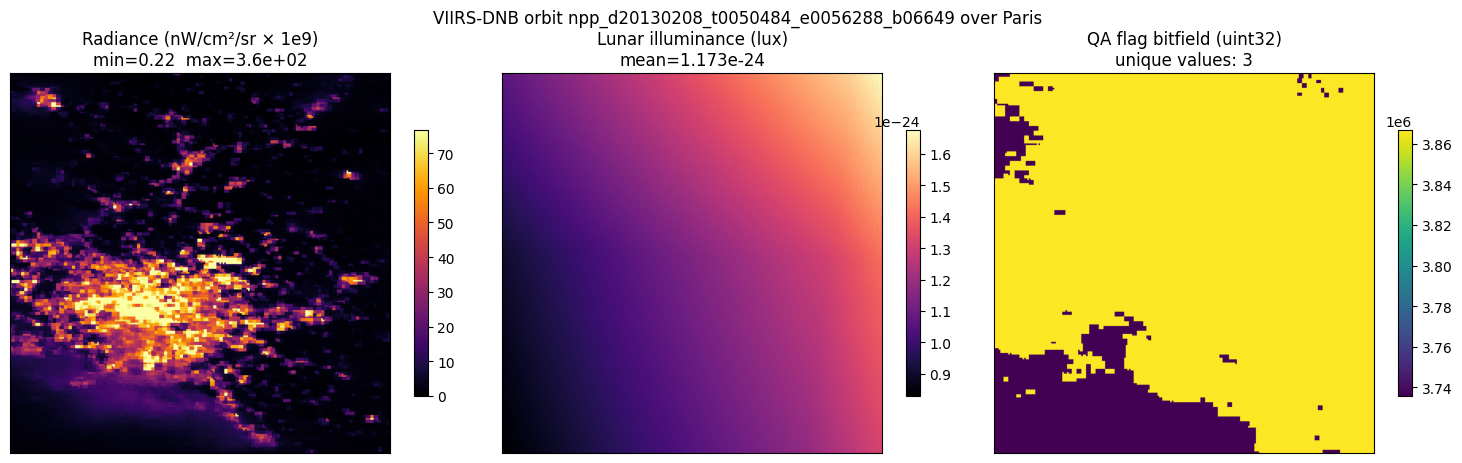

In [9]:
# Visualize the three co-located layers for this orbit.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
with rasterio.open(paths['radiance']) as src:
    rad = src.read(1)
with rasterio.open(paths['li']) as src:
    li = src.read(1)
with rasterio.open(paths['flag']) as src:
    flag = src.read(1)

im0 = axes[0].imshow(rad, cmap='inferno', vmin=0, vmax=np.quantile(rad[rad > 0], 0.98) if (rad > 0).any() else 1)
axes[0].set_title(f'Radiance (nW/cm²/sr × 1e9)\nmin={rad.min():.2g}  max={rad.max():.2g}')
plt.colorbar(im0, ax=axes[0], shrink=0.7)

im1 = axes[1].imshow(li, cmap='magma')
axes[1].set_title(f'Lunar illuminance (lux)\nmean={np.nanmean(li):.4g}')
plt.colorbar(im1, ax=axes[1], shrink=0.7)

im2 = axes[2].imshow(flag, cmap='viridis')
axes[2].set_title(f'QA flag bitfield (uint32)\nunique values: {len(np.unique(flag))}')
plt.colorbar(im2, ax=axes[2], shrink=0.7)
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f'VIIRS-DNB orbit {orbit.orbit_id} over Paris', y=1.02)
plt.tight_layout(); plt.show()

## 6. Stage 2: Per-orbit cleaning (`OrbitPrep`)

**What it does.** Mask out moonlit and bad pixels, then warp the orbit
onto a per-sensor common ROI grid (DMSP at 30 arc-sec, VIIRS at 15
arc-sec). Output is a single radiance raster with NaN where data was
rejected, plus a co-registered LI raster.

**Lunar mask.** Three modes; default is `"zero"`:

$$
M_{\mathrm{lunar}}(p) =
\begin{cases}
  \mathbb{1}\bigl[(\mathrm{flag}_p \!\gg\! b)\;\&\;1 = 1\bigr] & \text{mode} = \text{zero},\ b = b_{\mathrm{sat}} \\\\
  \mathbb{1}\bigl[0 \le \mathrm{LI}_p < \tau\bigr] & \text{mode} = \text{low} \\\\
  1 & \text{mode} = \text{all}
\end{cases}
$$

where $b_{\mathrm{sat}}$ is the sensor's zero-LI bit position (11 for
DMSP-OLS, 5 for VIIRS-DNB) and $\tau$ defaults to 0.1 lux. The `"zero"`
mode reproduces the EOG annual-composite convention: keep only orbits
where the moon's contribution to surface illuminance was effectively
below the sensor's noise floor.

**Validity mask.** Catches sentinel values that aren't real
observations:

$$
M_{\mathrm{valid}}(p) = \mathbb{1}[\mathrm{LI}_p \ge 0]
  \cdot \mathbb{1}[\mathrm{LI}_p \text{ is finite}]
  \cdot \mathbb{1}[r_p \in [r_{\min}, r_{\max}]]
$$

with $[r_{\min}, r_{\max}] = [0, 63]$ for DMSP (uint8 sensor range, 255 is the fill
value) and $[0, 10^9]$ for VIIRS. The `LI ≥ 0` check uniformly rejects
both `-1.0` (DMSP nodata) and `-999.3` (VIIRS / no-observation) without
needing to enumerate sentinel values per sensor.

**The combined mask** is $M = M_{\mathrm{lunar}} \cdot M_{\mathrm{valid}}$.
Pixels where $M = 0$ become NaN in the output.

**Warp.** Each cleaned orbit is then reprojected onto a per-sensor common
ROI grid (snapped to whole-pixel boundaries at the native resolution)
via `rasterio.warp.reproject` with `Resampling.average`. Same-grid
outputs across orbits make compositing in stage 3 a pure `np.stack`.

In [ ]:
# Inspect the lunar bit for this specific orbit.
# Whether bit 5 is set depends on the orbit's lunar illuminance — a high
# percentage means the orbit was acquired near new moon (good: most pixels
# will pass the zero-lunar mask).  A low percentage means it was acquired
# under partial moonlight and the lunar mask will reject most of this orbit,
# but other orbits in the same monthly composite will compensate.
zero_lunar_set = decode_bit(flag, VIIRS_ZERO_LUNAR_ILLUM_BIT)
pct = 100 * zero_lunar_set.mean()
print(f'VIIRS zero-lunar bit (bit 5) set in {pct:.1f}% of pixels')
if pct > 50:
    print('  → near-new-moon orbit: most pixels will pass the lunar mask')
else:
    print('  → moonlit orbit: lunar mask will reject most pixels here;')
    print('    other near-new-moon orbits in the same month will contribute to the composite')

# Show the three masks side by side.
cfg = SENSOR_CONFIGS[SENSOR_VIIRS]
lunar = make_lunar_mask(li, flag, cfg, mode='zero', low_thresh_lux=0.1)
validity = make_validity_mask(rad, li, cfg)
combined = lunar & validity

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, mask, title in zip(
    axes,
    [lunar, validity, combined],
    [f'Lunar mask (bit 5)\n{100*lunar.mean():.1f}% kept',
     f'Validity mask\n{100*validity.mean():.1f}% kept',
     f'Combined\n{100*combined.mean():.1f}% kept'],
):
    ax.imshow(mask, cmap='gray_r')
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Per-pixel masks for one VIIRS orbit', y=1.02)
plt.tight_layout(); plt.show()

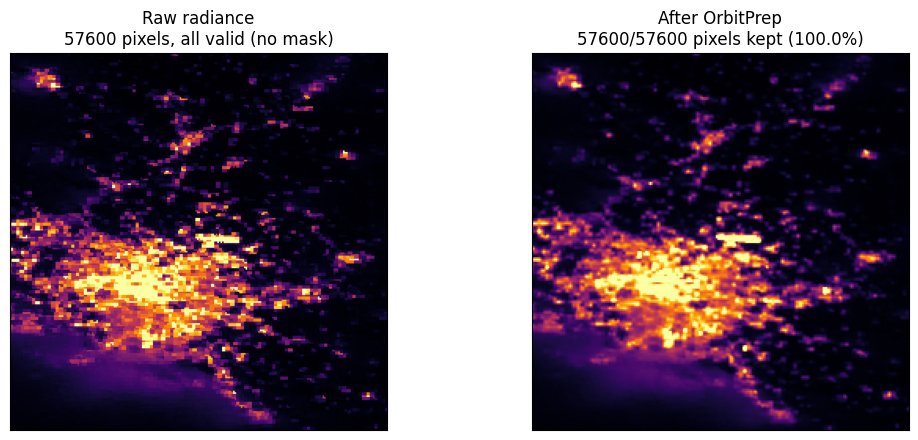

In [11]:
# Run the full OrbitPrep on one orbit and show before / after radiance.
prep = OrbitPrep(
    sensor=SENSOR_VIIRS,
    roi_bbox=PARIS_BBOX,
    dst_dir=TUTORIAL_CACHE / 'orbitprep',
    lunar_mask_mode='zero',
)
out = prep.transform({'orbit': orbit, 'radiance': paths['radiance'],
                      'li': paths['li'], 'flag': paths['flag']})

with rasterio.open(out['radiance']) as src:
    cleaned = src.read(1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
vmax = np.nanquantile(cleaned[np.isfinite(cleaned)], 0.98) if np.isfinite(cleaned).any() else 1
axes[0].imshow(rad, cmap='inferno', vmin=0, vmax=vmax)
axes[0].set_title(f'Raw radiance\n{rad.size} pixels, all valid (no mask)')
axes[1].imshow(cleaned, cmap='inferno', vmin=0, vmax=vmax)
n_finite = int(np.isfinite(cleaned).sum())
axes[1].set_title(f'After OrbitPrep\n{n_finite}/{cleaned.size} pixels kept ({100*n_finite/cleaned.size:.1f}%)')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 7. Stage 3: Compositing

**What it does.** Reduce all cleaned orbits within a *period* (default:
month) to a single per-pixel composite using a robust reducer.

**Math.** For period $P$ and pixel $p$:

$$
\hat{r}_{p,P} = \underset{t \in P : M_{p,t}=1}{\mathrm{median}} r_{p,t}
$$

with auxiliary outputs

$$
n_{p,P} = \sum_{t \in P} M_{p,t},
\qquad
\overline{\mathrm{LI}}_{p,P} = \frac{1}{n_{p,P}} \sum_{t \in P : M_{p,t}=1} \mathrm{LI}_{p,t}.
$$

**Why median?** Nightly imagery is contaminated by transient sources
the QA flags don't catch such as: fires, lightning, gas flares, undetected
cloud edges, aurora. The median is robust against ~50% asymmetric
outliers; the mean is not. The EOG-published composites use median
(or trimmed mean) for the same reason. The compositor accepts
`method="mean"` if smoother results are wanted.

**Why this is now "ours".** With nightly granules and QA layers in
hand, we control the compositing rules, including the lunar threshold,
extra QA bits, and aggregation period. The published EOG annual
composites baked these decisions in; we can vary them per experiment.

In [12]:
# Pull a few days of orbits, run OrbitPrep on each, then composite.
viirs_records = ingest(
    PARIS_BBOX, WINDOW_START, WINDOW_END, SENSOR_VIIRS,
    cache_dir=TUTORIAL_CACHE / 'ingest',
)
print(f'ingested {len(viirs_records)} VIIRS orbits')

prep_v = OrbitPrep(SENSOR_VIIRS, PARIS_BBOX,
                   TUTORIAL_CACHE / 'orbitprep', lunar_mask_mode='zero')
viirs_prepped = [prep_v.transform(r) for r in viirs_records]

# Compositor reuses the OrbitPrep slug so its outputs land beside the
# matching prepped inputs in the cache.
viirs_comp = Compositor(
    SENSOR_VIIRS, TUTORIAL_CACHE / 'composite', roi_slug=prep_v.roi_slug,
).aggregate(viirs_prepped)
for c in viirs_comp:
    print(f'  composite period={c["period"]}: {c["n_orbits"]} orbits')


viirs_npp orbits: 100%|███████████████████████████████████████████████| 16/16 [00:03<00:00,  4.57orbit/s]


ingested 16 VIIRS orbits


viirs_npp composite: 100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 11.68period/s]

  composite period=201302: 16 orbits


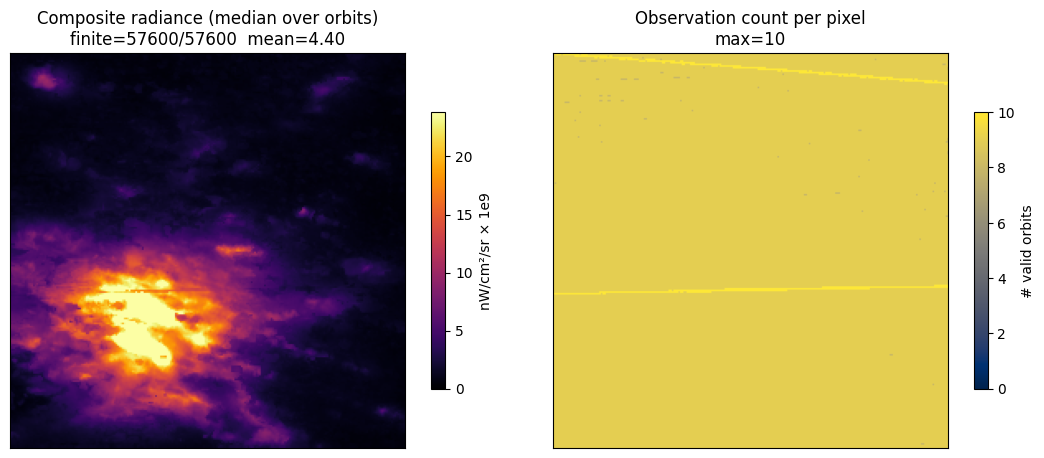

In [13]:
# Show the composite radiance + obs_count side by side.
with rasterio.open(viirs_comp[0]['radiance']) as src: comp_rad = src.read(1)
with rasterio.open(viirs_comp[0]['obs_count']) as src: comp_n = src.read(1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
finite = comp_rad[np.isfinite(comp_rad)]
vmax = np.quantile(finite, 0.98) if finite.size else 1
im0 = axes[0].imshow(comp_rad, cmap='inferno', vmin=0, vmax=vmax)
axes[0].set_title(f'Composite radiance (median over orbits)\n'
                  f'finite={finite.size}/{comp_rad.size}  '
                  f'mean={np.nanmean(comp_rad):.2f}')
plt.colorbar(im0, ax=axes[0], shrink=0.7, label='nW/cm²/sr × 1e9')
im1 = axes[1].imshow(comp_n, cmap='cividis', vmin=0)
axes[1].set_title(f'Observation count per pixel\nmax={comp_n.max()}')
plt.colorbar(im1, ax=axes[1], shrink=0.7, label='# valid orbits')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 8. Stage 4a: DMSP intercalibration (Li 2017 stepwise)

**The problem.** DMSP-OLS isn't a calibrated radiometer. The same
physical scene produces different DN values across the F10–F18
satellites and across years on a single satellite (sensor degradation,
onboard amplification gain changes, orbital drift). Without
correction, what looks like "economic growth" in a raw DMSP series
is partly just sensor drift.

**Li et al. 2017 stepwise method.** Build a quadratic that maps each
satellite-year's composite onto a single reference satellite-year
(F16 2007). Coefficients are derived from regression in
*pseudo-invariant target* regions where ground brightness shouldn't
have changed (e.g. specific Sicily regions for European calibration):

$$
\widetilde{X} = c_0 + c_1 X + c_2 X^2
$$

with sat-year-specific $(c_0, c_1, c_2)$. The F16 era is treated as
two-step: first a within-F16 yearly correction (`F16A`), then a global
F16→reference correction (`F16B`). F10 and F12 fall outside the
published coefficient set; the codebase falls back to plain clipping
into `[0, 63]` for those years.

**Alternative.** Locally-derived coefs from the user's ROI would be
more accurate but add complexity. The published coefs are reasonable
global defaults and reproduce the legacy pipeline's behavior; the
codebase preserves room for a local derivation later.

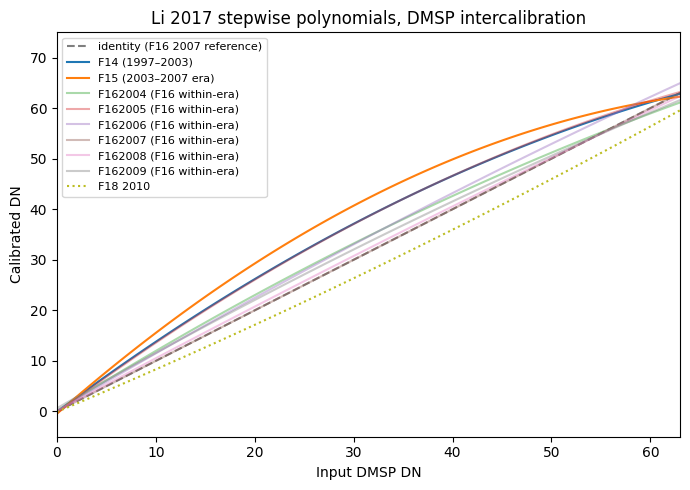

In [15]:
# Visualize each Li 2017 polynomial across the DMSP DN range [0, 63].
x = np.linspace(0, 63, 100)
fig, ax = plt.subplots(figsize=(7, 5))

def apply_poly(c, x): return c[0] + c[1]*x + c[2]*x**2

ax.plot(x, x, 'k--', label='identity (F16 2007 reference)', alpha=0.5)
ax.plot(x, apply_poly(PUBLISHED_COEFS['F14'], x), label='F14 (1997–2003)')
ax.plot(x, apply_poly(PUBLISHED_COEFS['F15'], x), label='F15 (2003–2007 era)')
for k, coef in sorted(PUBLISHED_COEFS['F16A'].items()):
    ax.plot(x, apply_poly(coef, x), alpha=0.4, label=f'{k} (F16 within-era)')
ax.plot(x, apply_poly(PUBLISHED_COEFS['F18'], x), label='F18 2010', linestyle=':')
ax.set_xlabel('Input DMSP DN'); ax.set_ylabel('Calibrated DN')
ax.set_title('Li 2017 stepwise polynomials, DMSP intercalibration')
ax.legend(loc='upper left', fontsize=8); ax.set_xlim(0, 63); ax.set_ylim(-5, 75)
plt.tight_layout(); plt.show()

## 8. Stage 4b: VIIRS preprocessing

**The problem.** VIIRS-DNB has a much wider dynamic range and finer
spatial resolution than DMSP-OLS, plus a stronger "blooming" response
to bright point sources (the latter is partly an artifact of the DNB
PSF and onboard processing). Feeding raw VIIRS into a regression
against DMSP would let bright pixels dominate and obscure the
dim-light end where DMSP has its real value.

**The recipe** (`harmonizer.transformers.viirsprep.VIIRSprep`):

1. **Damper.** Set $r \le \tau_d$ to zero (default $\tau_d = 1.0$
   nW·cm⁻²·sr⁻¹ × 10⁹). This is a noise-floor cut — DMSP saturates
   below ~0.5 DN, so anything below the threshold can't be matched anyway.
2. **Gaussian convolution** with a $(2\rho+1) \times (2\rho+1)$ kernel
   (default $\rho=5$, $\sigma=2$):

$$
k(i,j) = \frac{1}{Z}\exp\!\left(-\frac{i^2+j^2}{2\sigma^2}\right),
\qquad Z = \sum_{i,j} \exp\!\left(-\frac{i^2+j^2}{2\sigma^2}\right)
$$

    The convolution mimics DMSP's coarser PSF — without it, harmonizing
    a sharp VIIRS pixel against a blurred DMSP pixel just teaches the
    model to throw information away.
3. **`log1p` transform**, $f(r) = \ln(1 + r)$. Compresses the bright
    tail of the VIIRS distribution so the regression isn't dominated
    by gas flares and hyper-bright urban cores. `log1p` rather than
    `log` so zero stays zero.

VIIRS prep: 100%|██████████████████████████████████████████████████████| 1/1 [00:00<00:00, 41.42period/s]


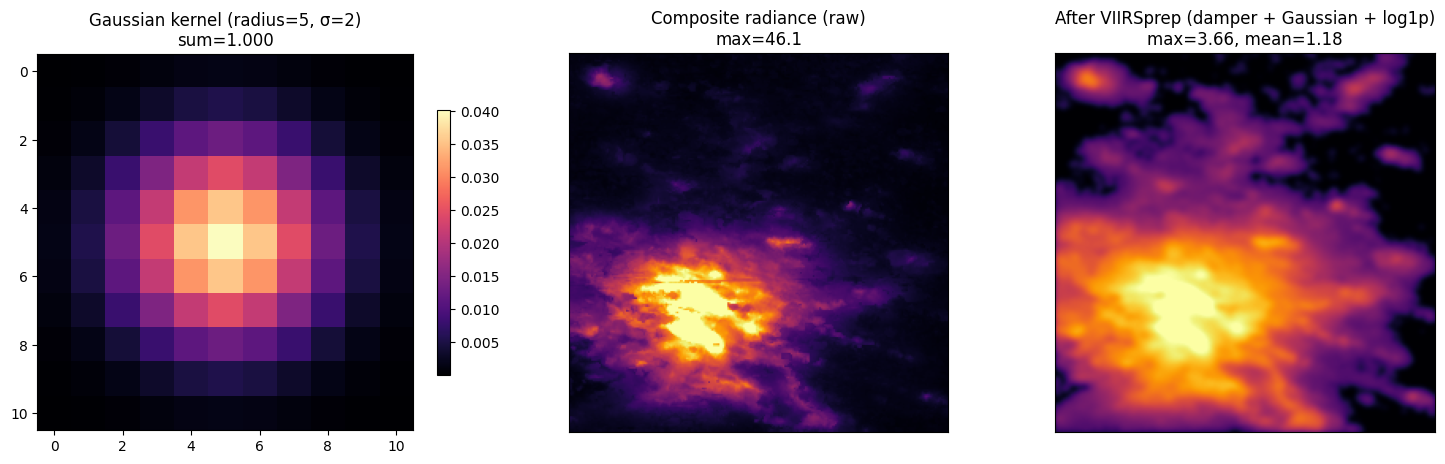

In [16]:
# Visualize the Gaussian kernel and the VIIRSprep effect.
kernel = get_kernel(pixelradius=5, sigma=2.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
im = axes[0].imshow(kernel, cmap='magma')
axes[0].set_title(f'Gaussian kernel (radius=5, σ=2)\nsum={kernel.sum():.3f}')
plt.colorbar(im, ax=axes[0], shrink=0.7)

# Apply VIIRSprep to the composite from stage 3.
viirs_pre = prep_viirs_composites(
    viirs_comp, TUTORIAL_CACHE / 'viirs_prepped', roi_slug=prep_v.roi_slug,
    usedask=False,
)
with rasterio.open(viirs_pre[0]['radiance']) as src: prepped = src.read(1)

vmax_raw = np.nanquantile(comp_rad[np.isfinite(comp_rad)], 0.98)
axes[1].imshow(comp_rad, cmap='inferno', vmin=0, vmax=vmax_raw)
axes[1].set_title(f'Composite radiance (raw)\nmax={np.nanmax(comp_rad):.1f}')
vmax_pre = np.nanquantile(prepped[np.isfinite(prepped)], 0.98)
axes[2].imshow(prepped, cmap='inferno', vmin=0, vmax=vmax_pre)
axes[2].set_title(f'After VIIRSprep (damper + Gaussian + log1p)\n'
                  f'max={np.nanmax(prepped):.2f}, mean={np.nanmean(prepped):.2f}')
for ax in axes[1:]: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


## 9. Stage 5: Harmonizer fit

**The setup.** With monthly composites for both sensors in 2013 (the
overlap year where DMSP F18 and VIIRS-NPP both operated), we have
paired pixels: VIIRS-prepped values $X$ and Li-calibrated DMSP DN
$y$. We fit a regression:

$$
\hat{y}_p = f(\mathbf{x}_p)
$$

where $\mathbf{x}_p$ can include polynomial expansions of the VIIRS
value and optional shifted-neighbor / index-grid features.

**Estimator choices** (`est=` in `Harmonizer`):
- `XGB()` — XGBoost regressor (default in `main.py`). Captures
  non-monotonic patterns where they exist.
- `CurveFit(degree=3)` — `sklearn` polynomial regression. Cheap,
  interpretable, good baseline.
- `NoFit()` — passthrough; useful for sanity-check ablations.

**Why train on overlap-year monthlies, not on the annual composite?**
12 paired frames means ~12× more training pixels per ROI, plus
intra-year variation (winter vs summer scene) gets baked into the
fit.

**Resampling.** VIIRS native is 15 arc-sec; DMSP is 30 arc-sec.
Default behaviour resamples VIIRS down to the DMSP grid for fitting
and inference (`downsampleVIIRS=True`). The alternative, upsample
DMSP to VIIRS native, preserves VIIRS resolution but implies more
DMSP precision than actually exists; see the `harmonize.py`
docstring for the discussion.

**NaN handling.** Composites carry real NaN nodata. Training
row-filters: any pixel where either sensor's value is NaN is
dropped from the fit. Inference preserves NaN through the pipeline.

In [17]:
# Build a quick paired DMSP+VIIRS month, then fit Harmonizer on it.
# (For a real run main.py trains on the full 2013 monthly stack;
# here we just want to demonstrate the fit/transform shape.)

PREFERRED_SATS = {'F18': ['2013']}  # F18 covers 2013 in the legacy table
dmsp_records = ingest(
    PARIS_BBOX, WINDOW_START, WINDOW_END, SENSOR_DMSP,
    cache_dir=TUTORIAL_CACHE / 'ingest',
    dmsp_preferred_sats=PREFERRED_SATS,
)
print(f'ingested {len(dmsp_records)} DMSP orbits')

prep_d = OrbitPrep(SENSOR_DMSP, PARIS_BBOX,
                   TUTORIAL_CACHE / 'orbitprep', lunar_mask_mode='zero')
dmsp_prepped = [prep_d.transform(r) for r in dmsp_records]
dmsp_comp = Compositor(
    SENSOR_DMSP, TUTORIAL_CACHE / 'composite', roi_slug=prep_d.roi_slug,
).aggregate(dmsp_prepped)
dmsp_calib = calibrate_dmsp_composites(
    dmsp_comp, TUTORIAL_CACHE / 'calib', PREFERRED_SATS, roi_slug=prep_d.roi_slug,
)

train_periods = sorted(
    {c['period'] for c in dmsp_calib} & {c['period'] for c in viirs_pre}
)
print(f'training periods (DMSP ∩ VIIRS): {train_periods}')

harmonized_dir = TUTORIAL_CACHE / 'harmonized'
h = Harmonizer(
    dmsp_period_dir=TUTORIAL_CACHE / 'calib' / prep_d.roi_slug,
    viirs_period_dir=TUTORIAL_CACHE / 'viirs_prepped' / prep_v.roi_slug,
    output_dir=harmonized_dir,
    train_periods=train_periods,
    est=CurveFit(degree=3),
    polyX=False,  # CurveFit does its own polynomial expansion
)
h.fit()


dmsp orbits: 100%|████████████████████████████████████████████████████| 31/31 [00:25<00:00,  1.23orbit/s]


ingested 31 DMSP orbits


DMSP calibrate: 100%|█████████████████████████████████████████████████| 1/1 [00:00<00:00, 200.65period/s]


training periods (DMSP ∩ VIIRS): ['201302']


harmonizer train prep: 100%|██████████████████████████████████████████| 1/1 [00:00<00:00, 129.12period/s]


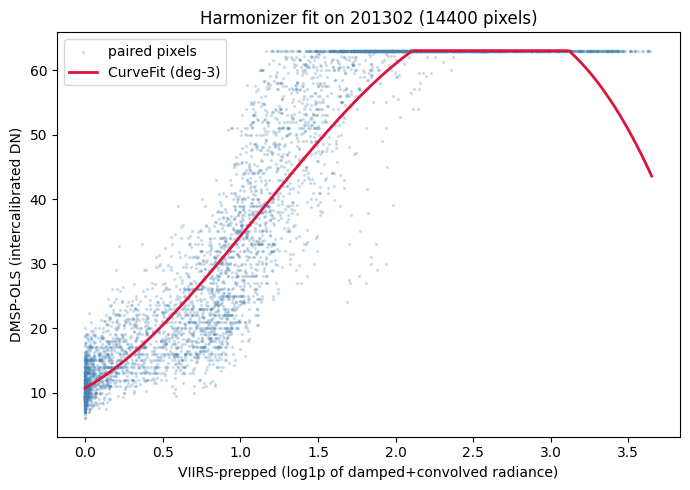

In [18]:
# Show what the fit learned: scatter of paired pixels + the fitted curve.
viirs_arr, dmsp_arr, _ = h._read_aligned_pair(train_periods[0])
valid = np.isfinite(viirs_arr) & np.isfinite(dmsp_arr)
x = viirs_arr[valid]
y = dmsp_arr[valid]

x_grid = np.linspace(x.min(), x.max(), 200)
X_grid, _ = h.Xy_transform(x_grid.reshape(-1, 1).astype(np.float32))
y_grid = h.est.predict(X_grid)

fig, ax = plt.subplots(figsize=(7, 5))
# Subsample for plotting; alpha to see density.
idx = np.random.choice(x.size, size=min(5000, x.size), replace=False)
ax.scatter(x[idx], y[idx], s=2, alpha=0.2, color='steelblue', label='paired pixels')
ax.plot(x_grid, np.clip(y_grid, 0, 63), color='crimson', linewidth=2, label='CurveFit (deg-3)')
ax.set_xlabel('VIIRS-prepped (log1p of damped+convolved radiance)')
ax.set_ylabel('DMSP-OLS (intercalibrated DN)')
ax.set_title(f'Harmonizer fit on {train_periods[0]} ({x.size} pixels)')
ax.legend()
plt.tight_layout(); plt.show()

In [ ]:
from tqdm.auto import tqdm as tqdm_auto

# Show the VIIRS-prepped → harmonized → DMSP comparison for the first period.
demo_period = train_periods[0]
out_path = h.transform(demo_period)
with rasterio.open(out_path) as src: harmonized = src.read(1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
vmax = np.nanquantile(np.concatenate([
    dmsp_arr[np.isfinite(dmsp_arr)],
    harmonized[np.isfinite(harmonized)],
]), 0.98)
axes[0].imshow(viirs_arr, cmap='inferno')
axes[0].set_title('VIIRS-prepped (input)')
axes[1].imshow(harmonized, cmap='inferno', vmin=0, vmax=vmax)
axes[1].set_title('Harmonized (output, DMSP DN scale)')
axes[2].imshow(dmsp_arr, cmap='inferno', vmin=0, vmax=vmax)
axes[2].set_title('DMSP intercalibrated (target)')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f'Period {demo_period}: VIIRS → harmonized vs DMSP', y=1.02)
plt.tight_layout(); plt.show()

valid_h = np.isfinite(harmonized) & np.isfinite(dmsp_arr)
rmsd = float(np.sqrt(np.mean((harmonized[valid_h] - dmsp_arr[valid_h])**2)))
print(f'pixelwise RMSD between harmonized VIIRS and intercalibrated DMSP: {rmsd:.3f} DN')

# Transform all remaining periods so Section 11 has the full 12-month series.
remaining = [p for p in train_periods if p != demo_period]
for period in tqdm_auto(remaining, desc='transforming remaining periods'):
    h.transform(period)
print(f'\nAll {len(train_periods)} periods written to {TUTORIAL_CACHE / "harmonized"}')

## 10. Sparse long-span time series

The step-by-step pipeline above covers 2013 (12 monthly composites). To
demonstrate harmonization's actual value — a coherent 1993–2022 nighttime
lights record on a single scale — we need DMSP data from before 2013 and
VIIRS data from after it.

**Why sparse sampling?** Ingesting every orbit for every month across 30 years
takes 8–12 hours cold start. For a demo, **one month per year** (January) gives
the same longitudinal picture at roughly 1/12 the cost. January is used for all
years so any cross-year DN differences reflect real change, not seasonal bias.

**What the loop does:**

- *DMSP years (≤ 2012)*: ingest → orbitprep → composite → Li 2017 calibration.
  Output lands in `TUTORIAL_CACHE/calib/roi-.../` alongside the 2013 DMSP data
  already produced in Stage 4.
- *VIIRS years (≥ 2014)*: ingest → orbitprep → composite → VIIRSprep → apply
  the harmonizer `h` trained on 2013 in Stage 5.
  Output lands in `TUTORIAL_CACHE/harmonized/` alongside the 2013 VIIRS data
  already produced in Stage 6.

Section 11 loads from both cache directories and plots the full combined series.

**For a full monthly series**, replace the sparse loop with `main.py`:

```bash
# Transition era only (~90 min cold start):
python -m harmonizer.main \
  -n paris_transition \
  --roi "2.0,48.5,3.0,49.5" \
  --start 2010-01-01 --end 2023-12-31 \
  --train-year 2013

# Full three-decade span (~8–12 hrs cold start):
python -m harmonizer.main \
  -n paris_full \
  --roi "2.0,48.5,3.0,49.5" \
  --start 1992-01-01 --end 2023-12-31 \
  --train-year 2013
```

Then in Section 11, uncomment the `main.py` path block in the loader cell.

In [ ]:
# ── Sparse year selection ────────────────────────────────────────────────────
# One representative year per DMSP satellite era + VIIRS years post-2013.
# Edit this list to add density or speed up the demo.
# 2013 is intentionally excluded — it is fully covered by Stages 1-6.
#
#   Satellite   Years in config
#   F10         1992–1994  (clip-only calibration, no Li 2017 polynomial)
#   F12         1995–1996  (clip-only calibration)
#   F14         1997–2003  (Li 2017 calibrated)
#   F16         2004–2009  (Li 2017 calibrated)
#   F18         2010–2013  (Li 2017 calibrated)
#   VIIRS-NPP   2012–present (harmonized via Stage 5 model)

SPARSE_YEARS = [
    1993,   # F10 — early DMSP, clip-only calibration
    1996,   # F12 — clip-only calibration
    2001,   # F14 era
    2005,   # F16 era
    2009,   # F16 late era
    2012,   # F18 final DMSP year before overlap
    # 2013 already done in Stages 1-6
    2014,   # first post-overlap VIIRS year
    2017,   # mid-VIIRS era
    2020,   # VIIRS — includes COVID-19 lockdown period
    2022,   # recent VIIRS
]

print(f'Sparse years: {SPARSE_YEARS}')
print(f'Each year: January only (1 monthly composite)')
print(f'Expected output: {len(SPARSE_YEARS)} additional composites + 12 from 2013 = '
      f'{len(SPARSE_YEARS) + 12} total data points across '
      f'{SPARSE_YEARS[-1] - SPARSE_YEARS[0] + 1} years')
print()
print('NOTE: this cell requires Stages 1–6 to have been run (needs trained harmonizer h).')

In [ ]:
from tqdm.auto import tqdm as tqdm_auto
from harmonizer.config import DMSP_PREFERRED_SATS

def _sat_for_year(year):
    for sat, years in DMSP_PREFERRED_SATS.items():
        if str(year) in years:
            return sat
    return None

for year in tqdm_auto(SPARSE_YEARS, desc='sparse year sample'):
    jan_start = datetime(year, 1,  1, tzinfo=timezone.utc)
    jan_end   = datetime(year, 1, 31, 23, 59, tzinfo=timezone.utc)

    if year <= 2013:
        # ── DMSP era ────────────────────────────────────────────────────────
        sat = _sat_for_year(year)
        if sat is None:
            print(f'  {year}: no DMSP satellite mapping in config — skipping')
            continue
        preferred = {sat: [str(year)]}

        records = ingest(PARIS_BBOX, jan_start, jan_end, SENSOR_DMSP,
                         TUTORIAL_CACHE / 'ingest', dmsp_preferred_sats=preferred)
        if not records:
            print(f'  {year} ({sat}): no DMSP orbits found — skipping')
            continue

        prep_yr = OrbitPrep(SENSOR_DMSP, PARIS_BBOX,
                            TUTORIAL_CACHE / 'orbitprep', lunar_mask_mode='zero')
        prepped = [prep_yr.transform(r) for r in records]
        comps   = Compositor(SENSOR_DMSP, TUTORIAL_CACHE / 'composite',
                             roi_slug=prep_yr.roi_slug).aggregate(prepped)
        calib   = calibrate_dmsp_composites(comps, TUTORIAL_CACHE / 'calib',
                                            preferred, roi_slug=prep_yr.roi_slug)
        print(f'  {year} ({sat}): {len(calib)} DMSP composite(s) calibrated '
              f'→ {[c["period"] for c in calib]}')

    else:
        # ── VIIRS era ────────────────────────────────────────────────────────
        records = ingest(PARIS_BBOX, jan_start, jan_end, SENSOR_VIIRS,
                         TUTORIAL_CACHE / 'ingest')
        if not records:
            print(f'  {year} (VIIRS): no orbits found — skipping')
            continue

        prep_yr  = OrbitPrep(SENSOR_VIIRS, PARIS_BBOX,
                             TUTORIAL_CACHE / 'orbitprep', lunar_mask_mode='zero')
        prepped  = [prep_yr.transform(r) for r in records]
        comps    = Compositor(SENSOR_VIIRS, TUTORIAL_CACHE / 'composite',
                              roi_slug=prep_yr.roi_slug).aggregate(prepped)
        vprepped = prep_viirs_composites(comps, TUTORIAL_CACHE / 'viirs_prepped',
                                         roi_slug=prep_yr.roi_slug, usedask=False)
        for vp in vprepped:
            out = h.transform(vp['period'])
            if out:
                print(f'  {year} (VIIRS): harmonized {vp["period"]} → {out.name}')
            else:
                print(f'  {year} (VIIRS): {vp["period"]} — no valid pixels after masking')

print('\nSparse sampling complete.')
print(f'Results are in the tutorial cache alongside the 2013 data:')
print(f'  DMSP calibrated : {TUTORIAL_CACHE / "calib"}')
print(f'  VIIRS harmonized: {TUTORIAL_CACHE / "harmonized"}')

## 11. Time-series exploration: the harmonized long record

This section loads the output of a `main.py` run (Section 10) and produces
the longitudinal view that demonstrates the real value of harmonization:
**calibrated DMSP and harmonized VIIRS on a single DN scale, with no
visible step at the sensor handoff**.

Set `TRIAL_NAME` below to whichever trial you ran. The loader reads from
two directories automatically:

| Source | Location |
|--------|----------|
| Harmonized VIIRS | `output/{TRIAL_NAME}/{YYYYMM}/radiance.tif` |
| Calibrated DMSP | `data/cache/calibrated/{roi_slug}/{YYYYMM}/radiance.tif` |

If the long-span trial hasn't been run yet, the cells fall back to the
tutorial-cache 2013 data and print a notice. Running the 2010–2016 transition
window (the shorter command in Section 10) is enough to see the cross-platform
handoff — the full 1992–2023 run adds the deeper DMSP history.

In [ ]:
import tempfile
from datetime import datetime
from pathlib import Path

import numpy as np
import rasterio

from harmonizer.constants import SENSOR_DMSP
from harmonizer.transformers.orbitprep import OrbitPrep

# ── Data sources ─────────────────────────────────────────────────────────────
# Default: tutorial cache populated by Stages 1-6 + the Section 10 sparse loop.
# The DMSP roi_slug is deterministic from PARIS_BBOX + DMSP pixel size.
_prep = OrbitPrep(SENSOR_DMSP, PARIS_BBOX, Path(tempfile.mkdtemp()), 'zero')

viirs_harm_dir = TUTORIAL_CACHE / 'harmonized'
dmsp_calib_dir = TUTORIAL_CACHE / 'calib' / _prep.roi_slug

# ── Alternative: main.py full-run output ─────────────────────────────────────
# Uncomment to load a full monthly series produced by the main.py commands
# in Section 10 instead of the sparse tutorial-cache data.
#
# from harmonizer.config import CALIB_DIR, OUTPUT
# TRIAL = 'paris_full'   # or 'paris_transition'
# viirs_harm_dir = OUTPUT / TRIAL
# dmsp_calib_dir = CALIB_DIR / _prep.roi_slug
# ─────────────────────────────────────────────────────────────────────────────

print(f'VIIRS harmonized : {viirs_harm_dir}  (exists={viirs_harm_dir.exists()})')
print(f'DMSP calibrated  : {dmsp_calib_dir}  (exists={dmsp_calib_dir.exists()})')


def _valid(arr):
    return arr[np.isfinite(arr) & (arr > 0)]


def load_combined_series(viirs_dir, dmsp_dir=None):
    """Load calibrated DMSP + harmonized VIIRS into a single sorted list.

    Returns
    -------
    list of (period_str, sensor_str, np.ndarray)
        period_str : 'YYYYMM'
        sensor_str : 'dmsp' | 'viirs'
        array      : float32, NaN for nodata; positive values are DN (0–63)
    Sorted by period so DMSP and VIIRS interleave at the 2013 boundary.
    """
    entries = []
    for label, root in (('viirs', viirs_dir), ('dmsp', dmsp_dir)):
        if root is None or not Path(root).exists():
            continue
        for period_dir in sorted(Path(root).iterdir()):
            rad = period_dir / 'radiance.tif'
            if not period_dir.is_dir() or not rad.exists():
                continue
            with rasterio.open(rad) as src:
                arr = src.read(1).astype(np.float32)
            entries.append((period_dir.name, label, arr))
    entries.sort(key=lambda x: x[0])
    return entries


combined      = load_combined_series(viirs_harm_dir, dmsp_calib_dir)
dmsp_entries  = [(p, a) for p, s, a in combined if s == 'dmsp']
viirs_entries = [(p, a) for p, s, a in combined if s == 'viirs']

print(f'\nLoaded {len(dmsp_entries)} DMSP + {len(viirs_entries)} VIIRS = {len(combined)} total')
if combined:
    span_start = combined[0][0][:4]
    span_end   = combined[-1][0][:4]
    print(f'  span: {combined[0][0]} → {combined[-1][0]}  ({span_start}–{span_end})')
    print(f'  (sparse years show as January-only points; 2013 shows all 12 months)')

In [ ]:
# Spatial snapshot — most recent harmonized VIIRS period.
# City lights should cluster in the NE quadrant (dense urban core + near suburbs);
# the rural southwest of the bbox should be visibly dimmer.
if not viirs_entries:
    print('[skip] no VIIRS harmonized periods loaded')
else:
    period, arr = viirs_entries[-1]
    valid = np.isfinite(arr) & (arr > 0)
    vmax = float(np.nanquantile(arr[valid], 0.99)) if valid.any() else 1.0

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(arr, cmap='inferno', vmin=0, vmax=vmax)
    ax.set_title(
        f'Harmonized radiance — {period}\n'
        f'Paris 1°×1° bbox  |  {int(valid.sum()):,} valid pixels  |  DMSP DN scale'
    )
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.04, label='harmonized DN (0–63)')
    plt.tight_layout()
    plt.show()

In [ ]:
# ── Combined DMSP + VIIRS time series ──────────────────────────────────────
# The key plot: both sensors on the same DN scale.  A well-fitted harmonizer
# shows no visible step where DMSP ends and VIIRS begins (2013 boundary).
# Reducers to try: np.nanmedian, np.nanmean, np.nansum (sum-of-lights).

REDUCER = np.nanmedian   # swap to np.nanmean or np.nansum to taste

def period_to_date(p):
    """'YYYYMM' → datetime at the 15th of that month."""
    return datetime(int(p[:4]), int(p[4:6]), 15)

def reduce_series(entries, reducer):
    dates, vals, counts = [], [], []
    for p, arr in entries:
        v = _valid(arr)
        dates.append(period_to_date(p))
        vals.append(float(reducer(v)) if v.size else np.nan)
        counts.append(int(v.size))
    return dates, vals, counts

dmsp_dates,  dmsp_vals,  dmsp_n  = reduce_series(dmsp_entries,  REDUCER)
viirs_dates, viirs_vals, viirs_n = reduce_series(viirs_entries, REDUCER)

if not combined:
    print('[skip] no data loaded — run the Section 10 main.py command first')
else:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 1]})

    # Main series
    if dmsp_dates:
        ax1.plot(dmsp_dates, dmsp_vals, 'o-', color='steelblue', ms=3, lw=1.4,
                 label='DMSP-OLS (Li 2017 calibrated)')
    if viirs_dates:
        ax1.plot(viirs_dates, viirs_vals, 's-', color='crimson', ms=3, lw=1.4,
                 label='VIIRS-DNB (harmonized)')

    # Highlight training year
    ax1.axvspan(datetime(2013, 1, 1), datetime(2014, 1, 1),
                alpha=0.10, color='gold', zorder=0, label='training year (2013)')
    ax1.axvline(datetime(2013, 1, 1), color='gray', lw=1.0, ls='--', alpha=0.6)

    reducer_name = REDUCER.__name__.replace('nan', '')
    ax1.set_ylabel(f'{reducer_name} DN (DMSP scale, 0–63)')
    ax1.set_title(
        f'Paris 1°×1° — harmonized nighttime lights  '
        f'({combined[0][0][:4]}–{combined[-1][0][:4]}, monthly)\n'
        f'DMSP-OLS (1992–2013) + VIIRS-DNB (2013–present) on a common scale'
    )
    ax1.legend(loc='upper left', fontsize=9)
    ax1.set_ylim(0, 63)

    # Valid-pixel count as context
    all_dates = [period_to_date(p) for p, _, _ in combined]
    all_n     = [int(_valid(a).size) for _, _, a in combined]
    colors    = ['steelblue' if s == 'dmsp' else 'crimson' for _, s, _ in combined]
    ax2.bar(all_dates, all_n, width=20, color=colors, alpha=0.5)
    ax2.axvline(datetime(2013, 1, 1), color='gray', lw=1.0, ls='--', alpha=0.6)
    ax2.set_ylabel('Valid pixels', fontsize=8)
    ax2.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()
    print(f'Tip: change REDUCER to np.nanmean or np.nansum (sum-of-lights) for different perspectives')

In [ ]:
# ── DN distribution heatmap ─────────────────────────────────────────────────
# For a long series, per-period violin plots become illegible.  A 2D heatmap
# (period × DN bin, colour = pixel density) shows how the *shape* of the
# distribution shifts over time — more informative than a single scalar summary.
# Structural changes (e.g. suburban expansion pushing the dark-pixel peak up,
# or LED retrofits compressing the bright tail) show as diagonal ridges.

if not combined:
    print('[skip] no data loaded')
else:
    DN_BINS = np.arange(0, 65, 1)          # 64 bins covering the full 0–63 range
    matrix  = np.full((len(combined), len(DN_BINS) - 1), np.nan)

    for i, (p, sensor, arr) in enumerate(combined):
        v = _valid(arr)
        if v.size:
            counts, _ = np.histogram(v, bins=DN_BINS)
            total = counts.sum()
            if total:
                matrix[i] = counts / total

    # X-axis: evenly-spaced index; tick every ~2 years for readability
    tick_step = max(1, len(combined) // 15)
    tick_idx  = list(range(0, len(combined), tick_step))
    tick_lbls = [combined[i][0][:6] for i in tick_idx]  # YYYYMM

    # Sensor boundary
    viirs_start = next((i for i, (_, s, _) in enumerate(combined) if s == 'viirs'), None)

    fig, ax = plt.subplots(figsize=(14, 5))
    im = ax.imshow(
        matrix.T, aspect='auto', origin='lower',
        extent=[-0.5, len(combined) - 0.5, 0, 63],
        cmap='magma', vmin=0,
    )
    if viirs_start is not None:
        ax.axvline(viirs_start - 0.5, color='white', lw=1.5, ls='--', alpha=0.8,
                   label=f'VIIRS era starts ({combined[viirs_start][0][:6]})')
        ax.legend(fontsize=8, loc='upper left')

    ax.set_xticks(tick_idx)
    ax.set_xticklabels(tick_lbls, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Harmonized DN (0–63)')
    ax.set_title(
        f'Paris 1°×1° — DN distribution over time  ({combined[0][0][:6]}–{combined[-1][0][:6]})\n'
        f'Colour = fraction of valid pixels at each DN bin per period  '
        f'(blue = DMSP era, red = VIIRS era in time-series plot)'
    )
    plt.colorbar(im, ax=ax, label='pixel fraction', shrink=0.8)
    plt.tight_layout()
    plt.show()

In [ ]:
# ── What to look for in the plots ───────────────────────────────────────────
#
# Time-series (cell above):
#   • Smooth continuity at the 2013 dashed line = harmonizer generalised well.
#   • A visible step up or down at the handoff = model under/over-predicts
#     the VIIRS→DMSP mapping; consider retraining with more training periods
#     or a higher-capacity estimator (XGB vs CurveFit).
#   • Seasonal cycles in the VIIRS era (not visible in DMSP) reflect VIIRS's
#     wider dynamic range and stricter lunar masking — more months are kept
#     near new moon, but winter nights are longer and cloud-free nights rarer
#     in Paris, so valid-pixel count (lower panel) dips in winter.
#
# Distribution heatmap:
#   • A bright ridge at high DN (top of plot) that persists across all years
#     = the saturated urban core; DMSP cannot distinguish within this mass.
#   • Any gradual upward shift in the lower-DN peak over the DMSP era
#     = suburban sprawl / electrification of the outer Île-de-France ring.
#   • A change in the width of the distribution at the VIIRS boundary
#     = VIIRS's larger dynamic range; the harmonizer compresses this back
#     toward the DMSP scale but may not fully eliminate it.
#
# To investigate further:
#   • Try REDUCER = np.nansum (sum-of-lights) — more sensitive to lit-area
#     growth than median DN, which saturates quickly in dense cities.
#   • Subset to a smaller inner bbox (e.g. the périphérique ring) vs outer
#     ring to separate core vs suburban trends.
print('Section 11 complete. See comments above for interpretation guidance.')

## 12. References

**Foundational NTL applications**
- Henderson, J.V., Storeygard, A., Weil, D.N. 2012. *Measuring Economic
  Growth from Outer Space.* American Economic Review 102(2): 994–1028.
- Min, B., Gaba, K.M., Sarr, O.F., Agalassou, A. 2013. *Detection of
  rural electrification in Africa using DMSP-OLS night lights imagery.*
  International Journal of Remote Sensing 34(22): 8118–8141.

**Sensor characterization**
- Elvidge, C.D., Baugh, K.E., Zhizhin, M., Hsu, F.-C., Ghosh, T. 2017.
  *VIIRS Night-time Lights.* International Journal of Remote Sensing
  38(21): 5860–5879.
- Mills, S., Weiss, S., Liang, C. 2013. *VIIRS day/night band stray
  light characterization and correction.* SPIE 8866.
- Román, M.O., et al. 2018. *NASA's Black Marble nighttime lights
  product suite.* Remote Sensing of Environment 210: 113–143.

**DMSP intercalibration (the recipe in `dmspcalibrate.py`)**
- Li, X., Zhao, L., Li, D., Xu, H. 2017. *An Improved Stepwise
  Calibration of DMSP-OLS Stable Nighttime Light Data.* Remote Sensing
  9(6): 637. https://www.mdpi.com/2072-4292/9/6/637

**Data archive**
- World Bank Light Every Night dataset:
  https://registry.opendata.aws/wb-light-every-night/
- World Bank *Open Nighttime Lights* tutorial:
  https://worldbank.github.io/OpenNightLights/

**This repo**
- See `README.md` for the full pipeline description and CLI usage.
- See `NTL_Harmonizer_Clay_Integration_Plan.md` for the longer roadmap
  (Clay foundation-model conditioning, lunar-stratified harmonization,
  metadata-feature ablations).